In [ ]:
import pandas as pd

df = pd.read_csv("ecommerce_sales_34500.csv")

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  cust

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


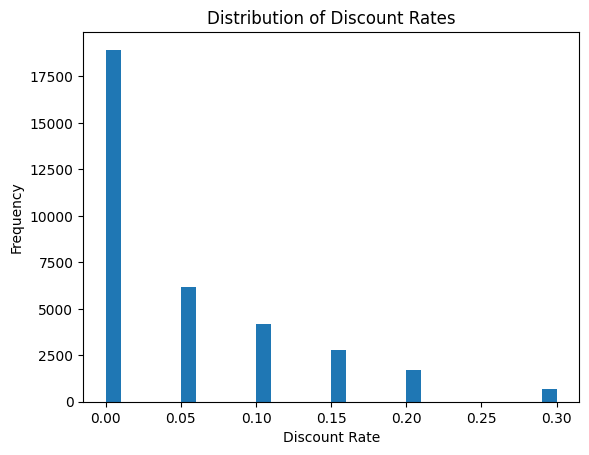

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['discount'], bins=30)
plt.xlabel("Discount Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Discount Rates")
plt.show()


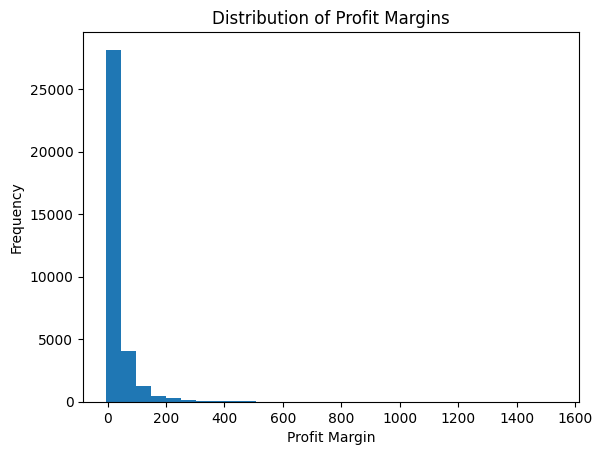

In [ ]:
plt.figure()
plt.hist(df['profit_margin'], bins=30)
plt.xlabel("Profit Margin")
plt.ylabel("Frequency")
plt.title("Distribution of Profit Margins")
plt.show()


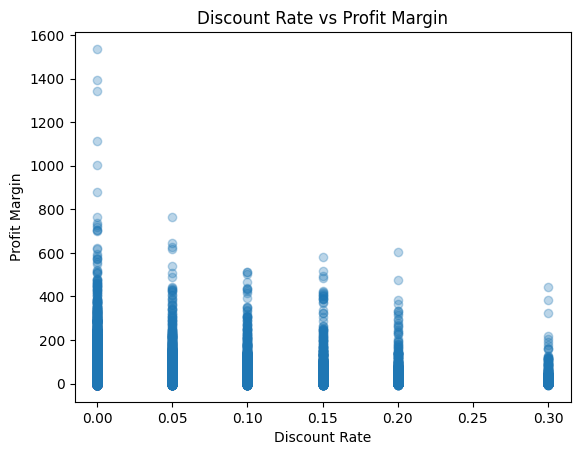

In [ ]:
plt.figure()
plt.scatter(df['discount'], df['profit_margin'], alpha=0.3)
plt.xlabel("Discount Rate")
plt.ylabel("Profit Margin")
plt.title("Discount Rate vs Profit Margin")
plt.show()


<Figure size 640x480 with 0 Axes>

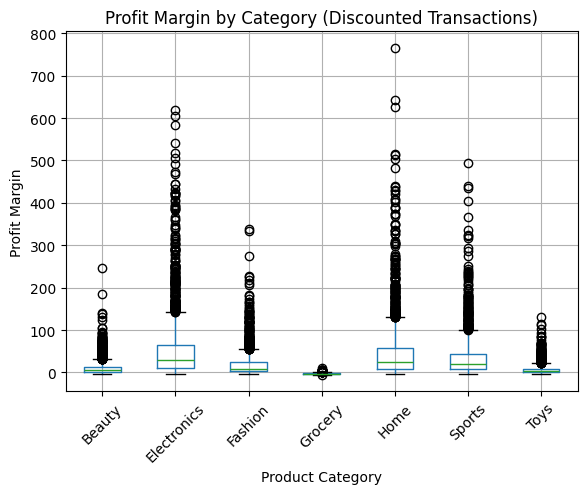

In [ ]:
df_discounted = df[df['discount'] > 0]

plt.figure()
df_discounted.boxplot(column='profit_margin', by='category', rot=45)
plt.xlabel("Product Category")
plt.ylabel("Profit Margin")
plt.title("Profit Margin by Category (Discounted Transactions)")
plt.suptitle("")
plt.show()


/tmp/ipython-input-2821667926.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_discounted['unit_revenue'] = (df_discounted['total_amount'] - df_discounted['shipping_cost']) / df_discounted['quantity']


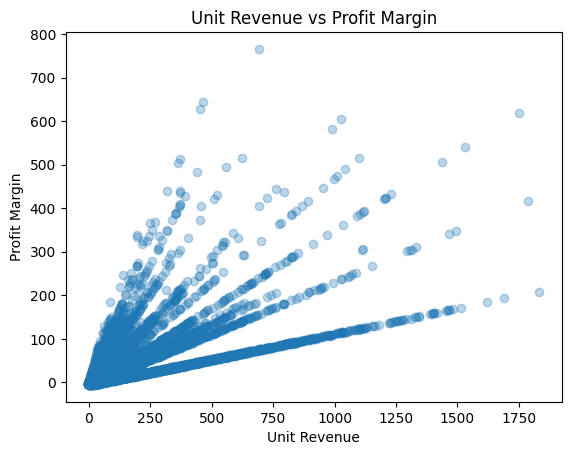

In [ ]:
df_discounted['unit_revenue'] = (df_discounted['total_amount'] - df_discounted['shipping_cost']) / df_discounted['quantity']

plt.figure()
plt.scatter(df_discounted['unit_revenue'], df_discounted['profit_margin'], alpha=0.3)
plt.xlabel("Unit Revenue")
plt.ylabel("Profit Margin")
plt.title("Unit Revenue vs Profit Margin")
plt.show()

/tmp/ipython-input-326321418.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_discounted['discount_value'] = df_discounted['price'] * df_discounted['quantity'] * df_discounted['discount']


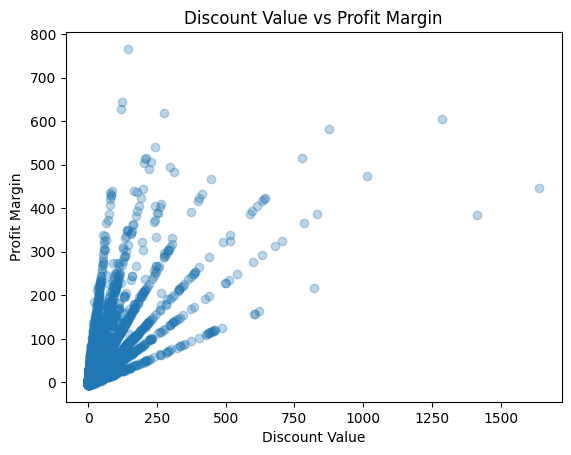

In [ ]:
df_discounted['discount_value'] = df_discounted['price'] * df_discounted['quantity'] * df_discounted['discount']

plt.figure()
plt.scatter(df_discounted['discount_value'], df_discounted['profit_margin'], alpha=0.3)
plt.xlabel("Discount Value")
plt.ylabel("Profit Margin")
plt.title("Discount Value vs Profit Margin")
plt.show()


#Linear Regression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1. Load the dataset
df = pd.read_csv('ecommerce_sales_34500.csv')

# --- 2. Feature Engineering ---

# Calculate Total Revenue (Price of Goods)
df['total_revenue'] = df['total_amount'] - df['shipping_cost']

# Create 'Unit Revenue' (Proxy for Unit Cost/Markup)
# Unit Revenue = Price Customer Paid per Unit
df['unit_revenue'] = df['total_revenue'] / df['quantity']

# Create 'Discount Value' (Absolute dollar impact of discount)
# Discount Value = (Original Price * Quantity) * Discount Rate
df['original_price_total'] = df['price'] * df['quantity']
df['discount_value'] = df['original_price_total'] * df['discount']

# --- 3. Filter for Discounted Products Only ---
df_discounted = df[df['discount'] > 0].copy()

# --- 4. Data Preparation on Filtered Data ---

# Select engineered features and category
X = df_discounted[['discount_value', 'unit_revenue', 'category']]
y = df_discounted['profit_margin']

# One-Hot Encode the 'category' feature (dropping the first for Linear Regression)
X = pd.get_dummies(X, columns=['category'], drop_first=True)

# Split the data (using same random_state=42 for consistency)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 5. Model Training (Linear Regression) ---

linear_model_discounted = LinearRegression()
linear_model_discounted.fit(X_train, y_train)

# --- 6. Model Evaluation ---

y_pred_linear_discounted = linear_model_discounted.predict(X_test)

# Calculate performance metrics
rmse_linear_discounted = np.sqrt(mean_squared_error(y_test, y_pred_linear_discounted))
r2_linear_discounted = r2_score(y_test, y_pred_linear_discounted)

print("--- Discounted Product Linear Regression Model Performance ---")
print(f"R-squared (R2) Score: {r2_linear_discounted:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear_discounted:.2f}")

# --- 7. Coefficient Interpretation ---

# Create a DataFrame to display feature names and their corresponding coefficients
coefficients_df_discounted = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': linear_model_discounted.coef_
})

# Add the intercept
intercept_df_discounted = pd.DataFrame({
    'Feature': ['Intercept'],
    'Coefficient': [linear_model_discounted.intercept_]
})

# Combine and print the results
full_coefficients_df_discounted = pd.concat([intercept_df_discounted, coefficients_df_discounted], ignore_index=True)

print("\n--- Discounted Product Linear Regression Coefficients ---")
print(full_coefficients_df_discounted.to_string(index=False))

--- Discounted Product Linear Regression Model Performance ---
R-squared (R2) Score: 0.6626
Root Mean Squared Error (RMSE): 25.94

--- Discounted Product Linear Regression Coefficients ---
             Feature  Coefficient
           Intercept     6.415694
      discount_value     0.413822
        unit_revenue     0.155640
category_Electronics   -31.928803
    category_Fashion     1.148545
    category_Grocery   -11.181027
       category_Home    10.921887
     category_Sports     7.775258
       category_Toys    -3.065452


#LR metrics

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_linear_discounted)
print(f"MAE: {mae:.4f}")

errors = y_test - y_pred_linear_discounted

print("Error mean:", errors.mean())
print("Error std:", errors.std())
print("5th percentile error:", np.percentile(errors, 5))
print("95th percentile error:", np.percentile(errors, 95))


# Add predictions back to test set
X_test_copy = X_test.copy()
X_test_copy['true_margin'] = y_test.values
X_test_copy['pred_margin'] = y_pred_linear_discounted

# Recover category labels
category_cols = [c for c in X_test_copy.columns if c.startswith("category_")]

X_test_copy['category'] = X_test_copy[category_cols].idxmax(axis=1)
X_test_copy['category'] = X_test_copy['category'].str.replace("category_", "")

category_mae = (
    X_test_copy
    .groupby('category')
    .apply(lambda g: np.mean(np.abs(g['true_margin'] - g['pred_margin'])))
    .sort_values()
)

print(category_mae)



# Reconstruct discount for test set
X_test_copy['discount'] = df_discounted.loc[X_test.index, 'discount']

# Create discount buckets
X_test_copy['discount_bucket'] = pd.cut(
    X_test_copy['discount'],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 1.0],
    labels=['0–10%', '10–20%', '20–30%', '30–40%', '40%+']
)

bucket_mae = (
    X_test_copy
    .groupby('discount_bucket')
    .apply(lambda g: np.mean(np.abs(g['true_margin'] - g['pred_margin'])))
)

print(bucket_mae)



def compute_sensitivity(model, base_df, category, discount_steps):
    rows = base_df[base_df['category'] == category].sample(200, random_state=42)
    sensitivities = []

    for d1, d2 in zip(discount_steps[:-1], discount_steps[1:]):
        rows1 = rows.copy()
        rows2 = rows.copy()

        rows1['discount'] = d1
        rows2['discount'] = d2

        rows1['discount_value'] = rows1['price'] * rows1['quantity'] * d1
        rows2['discount_value'] = rows2['price'] * rows2['quantity'] * d2

        X1 = pd.get_dummies(rows1[['discount_value','unit_revenue','category']])
        X2 = pd.get_dummies(rows2[['discount_value','unit_revenue','category']])

        X1, X2 = X1.align(X2, join='left', axis=1, fill_value=0)

        m1 = model.predict(X1).mean()
        m2 = model.predict(X2).mean()

        sensitivities.append((m2 - m1) / (d2 - d1))

    return np.mean(sensitivities)


MAE: 13.5971
Error mean: -0.6736504475700879
Error std: 25.937663653798563
5th percentile error: -21.00561290901946
95th percentile error: 34.254670350420625
category
Grocery         2.049483
Toys            5.110999
Fashion        11.119157
Electronics    16.655306
Sports         17.251812
Home           23.004754
dtype: float64
discount_bucket
0–10%     13.711472
10–20%    12.448086
20–30%    20.122348
30–40%          NaN
40%+            NaN
dtype: float64


/tmp/ipython-input-9590567.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.mean(np.abs(g['true_margin'] - g['pred_margin'])))
/tmp/ipython-input-9590567.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('discount_bucket')
/tmp/ipython-input-9590567.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_g

#Gradient Boosting Regressor

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1. Load the dataset
df = pd.read_csv('ecommerce_sales_34500.csv')

# --- 2. Feature Engineering ---

# Calculate Total Revenue (Price of Goods)
df['total_revenue'] = df['total_amount'] - df['shipping_cost']

# Create 'Unit Revenue' (Proxy for Unit Cost/Markup)
# Unit Revenue = Price Customer Paid per Unit
df['unit_revenue'] = df['total_revenue'] / df['quantity']

# Create 'Discount Value' (Absolute dollar impact of discount)
# Discount Value = (Original Price * Quantity) * Discount Rate
df['original_price_total'] = df['price'] * df['quantity']
df['discount_value'] = df['original_price_total'] * df['discount']

# --- 3. CRUCIAL STEP: Filter for Discounted Products Only ---
df_discounted = df[df['discount'] > 0].copy()

# --- 4. Data Preparation on Filtered Data ---

# Select engineered features and category
X = df_discounted[['discount_value', 'unit_revenue', 'category']]
y = df_discounted['profit_margin']

# One-Hot Encode the 'category' feature
X = pd.get_dummies(X, columns=['category'])

# Split the data (using same random_state=42 for consistency)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 5. Model Training (Gradient Boosting Regressor) ---

gbr_model_discounted = GradientBoostingRegressor(random_state=42)
gbr_model_discounted.fit(X_train, y_train)

# --- 6. Model Evaluation ---

y_pred_gbr_discounted = gbr_model_discounted.predict(X_test)

# Calculate performance metrics
rmse_gbr_discounted = np.sqrt(mean_squared_error(y_test, y_pred_gbr_discounted))
r2_gbr_discounted = r2_score(y_test, y_pred_gbr_discounted)

print("--- Discounted Product GBR Model Performance ---")
print(f"R-squared (R2) Score: {r2_gbr_discounted:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gbr_discounted:.2f}")

# --- 7. Feature Importance ---

# Create a DataFrame to display feature names and their corresponding importance scores
feature_importances_df_discounted = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gbr_model_discounted.feature_importances_
})

# Sort by importance
feature_importances_df_discounted = feature_importances_df_discounted.sort_values(
    by='Importance', ascending=False
).reset_index(drop=True)

print("\n--- Discounted Product GBR Feature Importances ---")
print(feature_importances_df_discounted.to_string(index=False))

--- Discounted Product GBR Model Performance ---
R-squared (R2) Score: 0.7765
Root Mean Squared Error (RMSE): 21.11

--- Discounted Product GBR Feature Importances ---
             Feature  Importance
      discount_value    0.562595
        unit_revenue    0.308578
category_Electronics    0.118516
       category_Home    0.004499
    category_Grocery    0.002442
     category_Beauty    0.002259
    category_Fashion    0.000698
       category_Toys    0.000413
     category_Sports    0.000000


#GBR metrics

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred_gbr_discounted)
print(f"MAE: {mae:.4f}")

errors = y_test - y_pred_gbr_discounted

print("Error mean:", errors.mean())
print("Error std:", errors.std())
print("5th percentile error:", np.percentile(errors, 5))
print("95th percentile error:", np.percentile(errors, 95))


# Add predictions back to test set
X_test_copy = X_test.copy()
X_test_copy['true_margin'] = y_test.values
X_test_copy['pred_margin'] = y_pred_gbr_discounted

# Recover category labels
category_cols = [c for c in X_test_copy.columns if c.startswith("category_")]

X_test_copy['category'] = X_test_copy[category_cols].idxmax(axis=1)
X_test_copy['category'] = X_test_copy['category'].str.replace("category_", "")

category_mae = (
    X_test_copy
    .groupby('category')
    .apply(lambda g: np.mean(np.abs(g['true_margin'] - g['pred_margin'])))
    .sort_values()
)

print(category_mae)



# Reconstruct discount for test set
X_test_copy['discount'] = df_discounted.loc[X_test.index, 'discount']

# Create discount buckets
X_test_copy['discount_bucket'] = pd.cut(
    X_test_copy['discount'],
    bins=[0, 0.1, 0.2, 0.3, 0.4, 1.0],
    labels=['0–10%', '10–20%', '20–30%', '30–40%', '40%+']
)

bucket_mae = (
    X_test_copy
    .groupby('discount_bucket')
    .apply(lambda g: np.mean(np.abs(g['true_margin'] - g['pred_margin'])))
)

print(bucket_mae)



def compute_sensitivity(model, base_df, category, discount_steps):
    rows = base_df[base_df['category'] == category].sample(200, random_state=42)
    sensitivities = []

    for d1, d2 in zip(discount_steps[:-1], discount_steps[1:]):
        rows1 = rows.copy()
        rows2 = rows.copy()

        rows1['discount'] = d1
        rows2['discount'] = d2

        rows1['discount_value'] = rows1['price'] * rows1['quantity'] * d1
        rows2['discount_value'] = rows2['price'] * rows2['quantity'] * d2

        X1 = pd.get_dummies(rows1[['discount_value','unit_revenue','category']])
        X2 = pd.get_dummies(rows2[['discount_value','unit_revenue','category']])

        X1, X2 = X1.align(X2, join='left', axis=1, fill_value=0)

        m1 = model.predict(X1).mean()
        m2 = model.predict(X2).mean()

        sensitivities.append((m2 - m1) / (d2 - d1))

    return np.mean(sensitivities)

MAE: 9.3218
Error mean: -0.2658787523298066
Error std: 21.11467528407335
5th percentile error: -20.195607966460877
95th percentile error: 27.836648015539108
category
Grocery         1.864165
Toys            3.581758
Beauty          4.268885
Fashion         7.442065
Sports         12.178429
Home           14.353055
Electronics    16.626566
dtype: float64
discount_bucket
0–10%      8.666890
10–20%     9.325420
20–30%    20.514823
30–40%          NaN
40%+            NaN
dtype: float64


/tmp/ipython-input-3173224795.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.mean(np.abs(g['true_margin'] - g['pred_margin'])))
/tmp/ipython-input-3173224795.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('discount_bucket')
/tmp/ipython-input-3173224795.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `

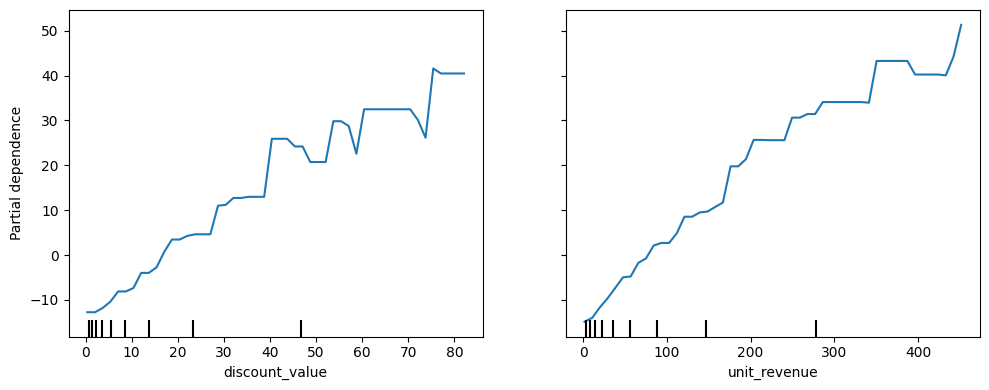

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

features_to_plot = ['discount_value', 'unit_revenue']

fig, ax = plt.subplots(figsize=(10, 4))
PartialDependenceDisplay.from_estimator(
    gbr_model_discounted,
    X_train,
    features_to_plot,
    grid_resolution=50,
    ax=ax
)
plt.tight_layout()
plt.show()


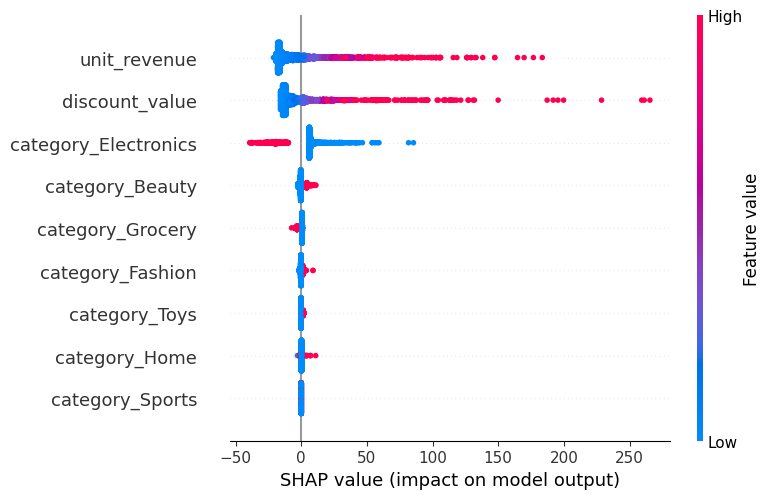

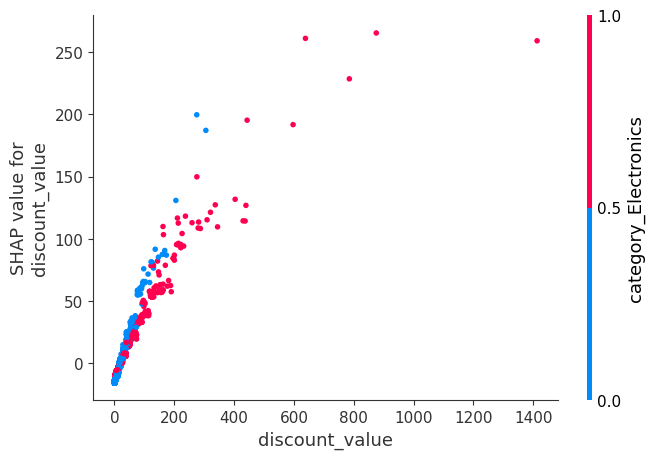

In [ ]:
import shap

explainer = shap.TreeExplainer(gbr_model_discounted)
shap_values = explainer.shap_values(X_test)

# Global importance
shap.summary_plot(shap_values, X_test)

# Dependence plot for discount
shap.dependence_plot(
    'discount_value',
    shap_values,
    X_test
)


## Simulations

In [ ]:
import numpy as np
import pandas as pd

discount_grid = np.linspace(0.01, 0.50, 50)  # 1% to 50%


In [ ]:
baseline = {
    "unit_revenue": X_train["unit_revenue"].mean(),
}

category_cols = [c for c in X_train.columns if c.startswith("category_")]
for c in category_cols:
    baseline[c] = 0

# Example: Electronics baseline
baseline["category_Electronics"] = 1


In [ ]:
sim_data = []

for d in discount_grid:
    row = baseline.copy()
    row["discount_value"] = row["unit_revenue"] * d
    sim_data.append(row)

sim_df = pd.DataFrame(sim_data)


##LR Simulation

In [ ]:
# Get the correct feature names from the linear regression model
lr_feature_names = linear_model_discounted.feature_names_in_

# Reindex the existing sim_df to match the LR model's feature names
# This will drop 'category_Beauty' if it exists in sim_df but not in lr_feature_names
# and add any missing features with fill_value=0 if they exist in lr_feature_names but not in sim_df.
sim_df = sim_df.reindex(columns=lr_feature_names, fill_value=0)

# Now predict
sim_df["pred_margin_lr"] = linear_model_discounted.predict(sim_df)

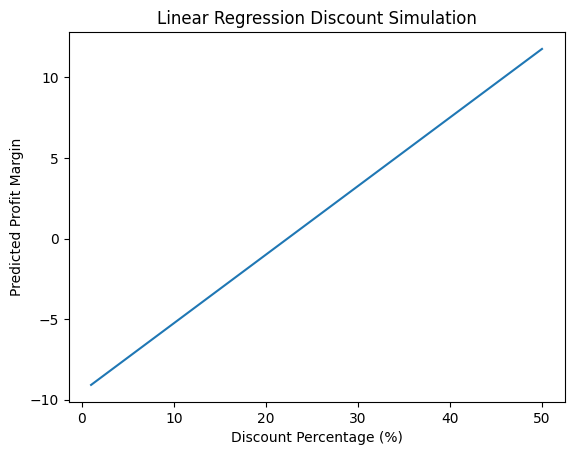

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(discount_grid * 100, sim_df["pred_margin_lr"])
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Predicted Profit Margin")
plt.title("Linear Regression Discount Simulation")
plt.show()


## GBR Simulation


In [ ]:
gbr_feature_names = gbr_model_discounted.feature_names_in_
sim_df = sim_df.reindex(columns=gbr_feature_names, fill_value=0)
sim_df["pred_margin_gbr"] = gbr_model_discounted.predict(sim_df)

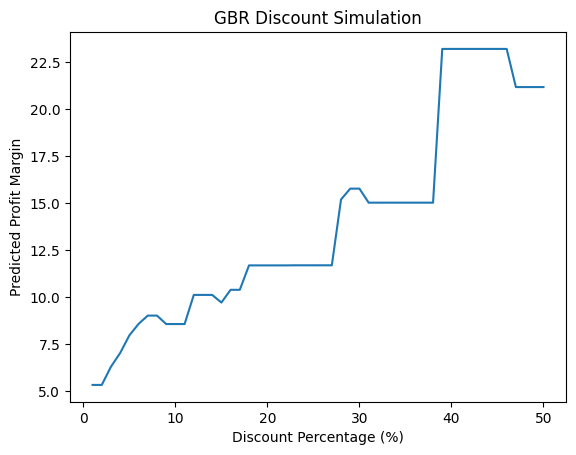

In [ ]:
plt.figure()
plt.plot(discount_grid * 100, sim_df["pred_margin_gbr"])
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Predicted Profit Margin")
plt.title("GBR Discount Simulation")
plt.show()


## Category wise Simulation

In [ ]:
results = []

for cat in category_cols:
    baseline_cat = baseline.copy()
    for c in category_cols:
        baseline_cat[c] = 0
    baseline_cat[cat] = 1

    for d in discount_grid:
        row = baseline_cat.copy()
        row["discount_value"] = row["unit_revenue"] * d
        results.append(row)

sim_all = pd.DataFrame(results)

# Prepare sim_all for Linear Regression prediction
lr_feature_names = linear_model_discounted.feature_names_in_
sim_all_for_lr = sim_all.reindex(columns=lr_feature_names, fill_value=0)
sim_all["pred_lr"] = linear_model_discounted.predict(sim_all_for_lr)

# Prepare sim_all for GBR prediction
gbr_feature_names = gbr_model_discounted.feature_names_in_
sim_all_for_gbr = sim_all.reindex(columns=gbr_feature_names, fill_value=0)
sim_all["pred_gbr"] = gbr_model_discounted.predict(sim_all_for_gbr)


NameError: name 'category_cols' is not defined

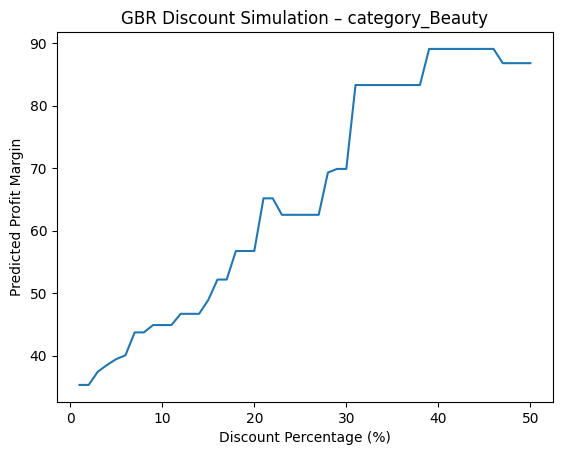

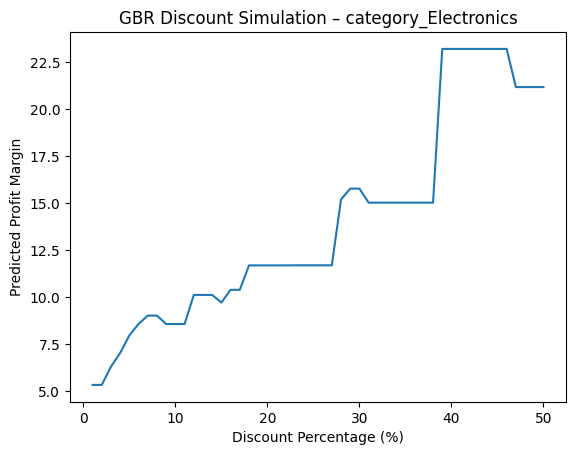

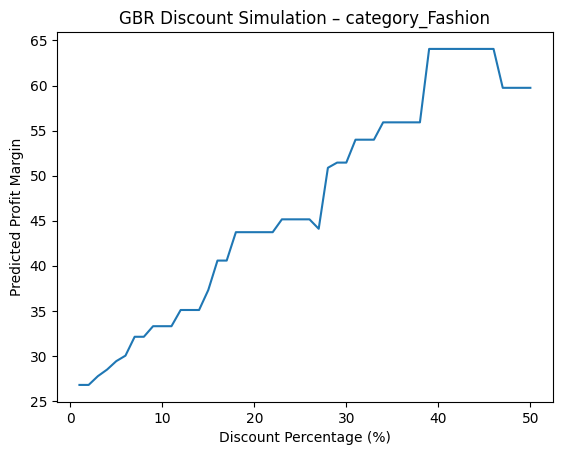

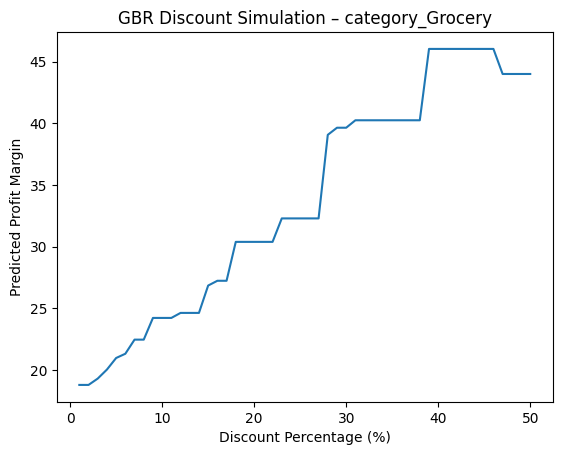

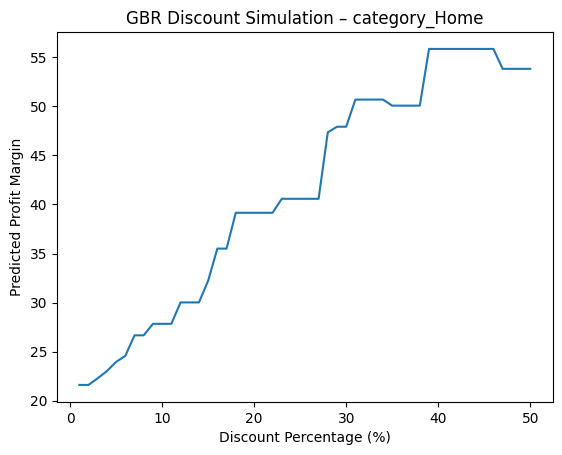

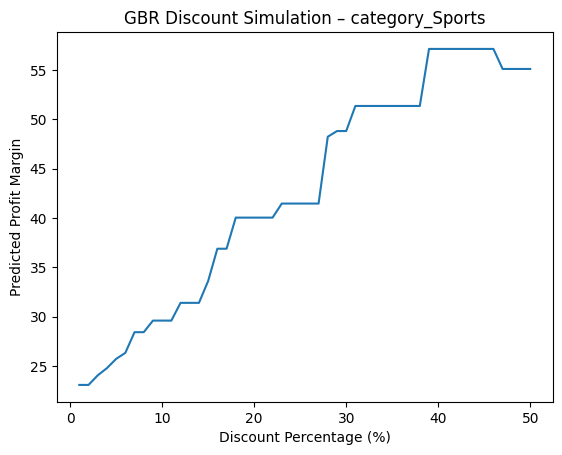

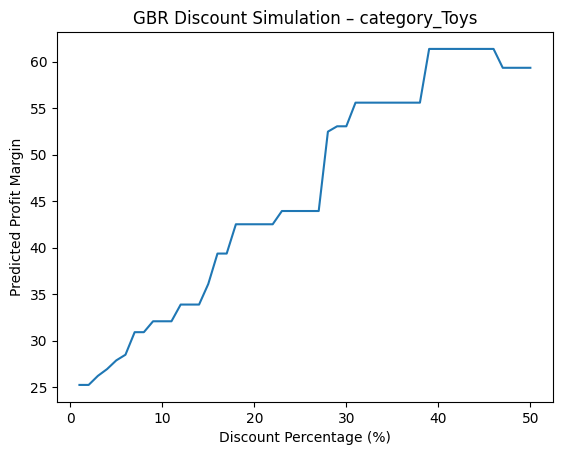

In [ ]:
for cat in category_cols:
    subset = sim_all[sim_all[cat] == 1]
    plt.figure()
    plt.plot(discount_grid * 100, subset["pred_gbr"])
    plt.title(f"GBR Discount Simulation – {cat}")
    plt.xlabel("Discount Percentage (%)")
    plt.ylabel("Predicted Profit Margin")
    plt.show()


## Fixed version??

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Discount grid: 1% to 50%
discount_grid = np.linspace(0.01, 0.50, 50)

# Feature names
lr_features = linear_model_discounted.feature_names_in_
gbr_features = gbr_model_discounted.feature_names_in_

# Category columns
category_cols = [c for c in lr_features if c.startswith("category_")]


In [ ]:
# Assume quantity = 1
quantity = 1

# Use mean unit revenue as baseline AFTER-discount revenue
baseline_unit_revenue = X_train["unit_revenue"].mean()

# Assume a modest baseline discount (for inversion stability)
baseline_discount = X_train["discount_value"].mean() / (
    X_train["unit_revenue"].mean() + X_train["discount_value"].mean()
)

# Infer pre-discount price
base_price = baseline_unit_revenue / (1 - baseline_discount)


In [ ]:
# Build baseline row
baseline = {}

# Initialize all features to zero
for f in lr_features:
    baseline[f] = 0

# Set category (example: Electronics)
baseline["category_Electronics"] = 1

sim_rows = []

for d in discount_grid:
    row = baseline.copy()

    # Price mechanics
    discount_value = base_price * d * quantity
    unit_revenue = base_price * (1 - d)

    row["discount_value"] = discount_value
    row["unit_revenue"] = unit_revenue

    sim_rows.append(row)

sim_df = pd.DataFrame(sim_rows)

# Ensure correct feature alignment
sim_df_lr = sim_df.reindex(columns=lr_features, fill_value=0)
sim_df_gbr = sim_df.reindex(columns=gbr_features, fill_value=0)

# Predictions
sim_df["pred_margin_lr"] = linear_model_discounted.predict(sim_df_lr)
sim_df["pred_margin_gbr"] = gbr_model_discounted.predict(sim_df_gbr)


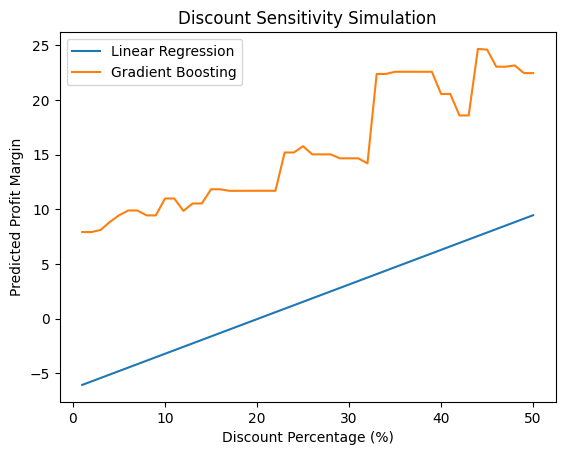

In [ ]:
plt.figure()
plt.plot(discount_grid * 100, sim_df["pred_margin_lr"], label="Linear Regression")
plt.plot(discount_grid * 100, sim_df["pred_margin_gbr"], label="Gradient Boosting")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Predicted Profit Margin")
plt.title("Discount Sensitivity Simulation")
plt.legend()
plt.show()


In [ ]:
all_results = []

for cat in category_cols:
    baseline_cat = {}

    for f in gbr_features:
        baseline_cat[f] = 0

    baseline_cat[cat] = 1

    for d in discount_grid:
        row = baseline_cat.copy()

        discount_value = base_price * d * quantity
        unit_revenue = base_price * (1 - d)

        row["discount_value"] = discount_value
        row["unit_revenue"] = unit_revenue

        row["discount_pct"] = d * 100
        row["category"] = cat

        all_results.append(row)

sim_all = pd.DataFrame(all_results)

# Predict
sim_all_gbr = sim_all.reindex(columns=gbr_features, fill_value=0)
sim_all["pred_margin_gbr"] = gbr_model_discounted.predict(sim_all_gbr)


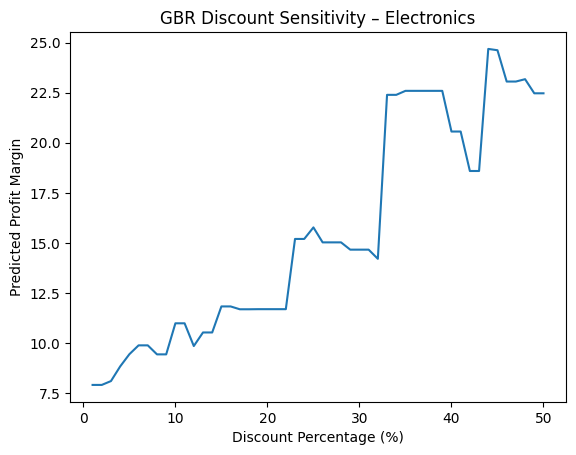

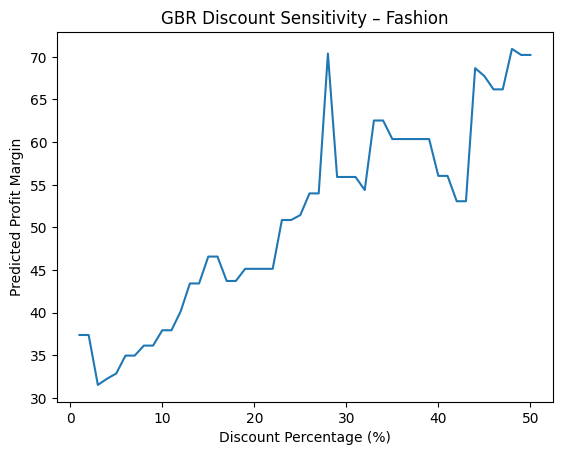

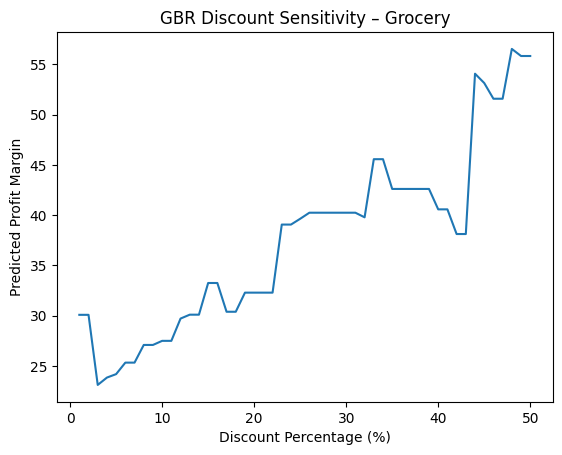

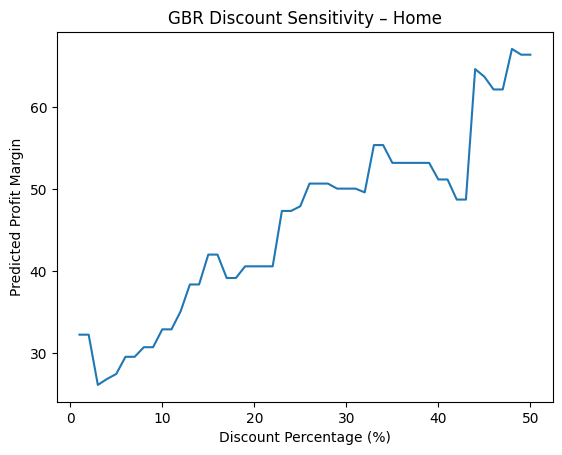

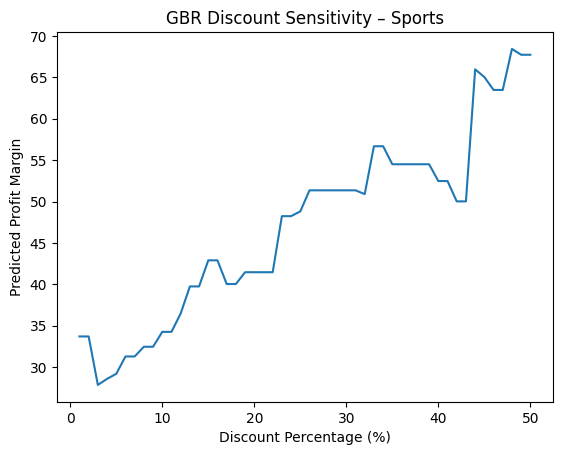

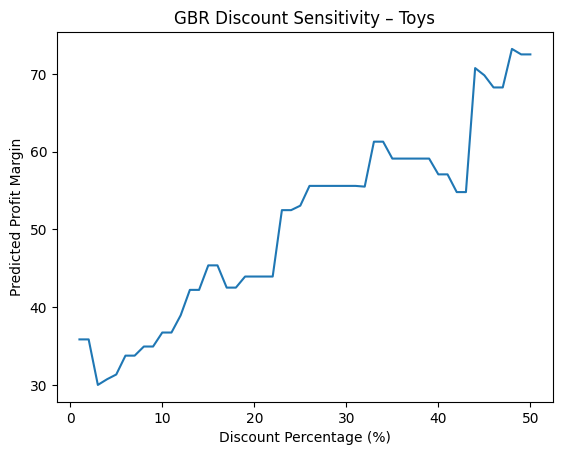

In [ ]:
for cat in category_cols:
    subset = sim_all[sim_all["category"] == cat]

    plt.figure()
    plt.plot(subset["discount_pct"], subset["pred_margin_gbr"])
    plt.xlabel("Discount Percentage (%)")
    plt.ylabel("Predicted Profit Margin")
    plt.title(f"GBR Discount Sensitivity – {cat.replace('category_', '')}")
    plt.show()


##Residual plot


In [ ]:
import pandas as pd

# Ensure X_test has the same columns as the LR model's training data
# lr_feature_names was created in a previous cell (wP-eCuBO64jh)
# It holds the column names that the linear_model_discounted was trained on.
X_test_lr = X_test.reindex(columns=lr_feature_names, fill_value=0)

# Predictions on test data
y_pred_lr = linear_model_discounted.predict(X_test_lr)
y_pred_gbr = gbr_model_discounted.predict(X_test)

# Residuals
residuals_lr = y_test - y_pred_lr
residuals_gbr = y_test - y_pred_gbr

In [ ]:
discount_pct_test = (
    X_test["discount_value"] /
    (X_test["unit_revenue"] + X_test["discount_value"])
) * 100


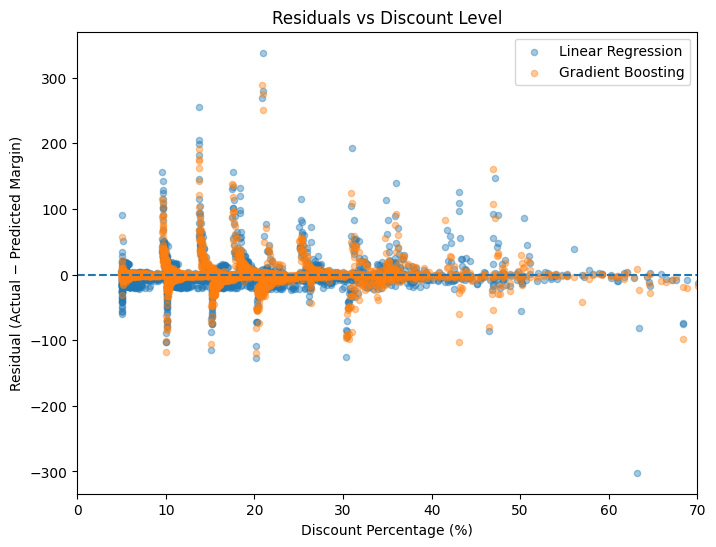

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    discount_pct_test,
    residuals_lr,
    alpha=0.4,
    label="Linear Regression",
    s=20
)

plt.scatter(
    discount_pct_test,
    residuals_gbr,
    alpha=0.4,
    label="Gradient Boosting",
    s=20
)

plt.axhline(0, linestyle="--")

plt.xlabel("Discount Percentage (%)")
plt.ylabel("Residual (Actual − Predicted Margin)")
plt.title("Residuals vs Discount Level")
plt.legend()
plt.xlim(0, 70) # Set x-axis limits
plt.show()

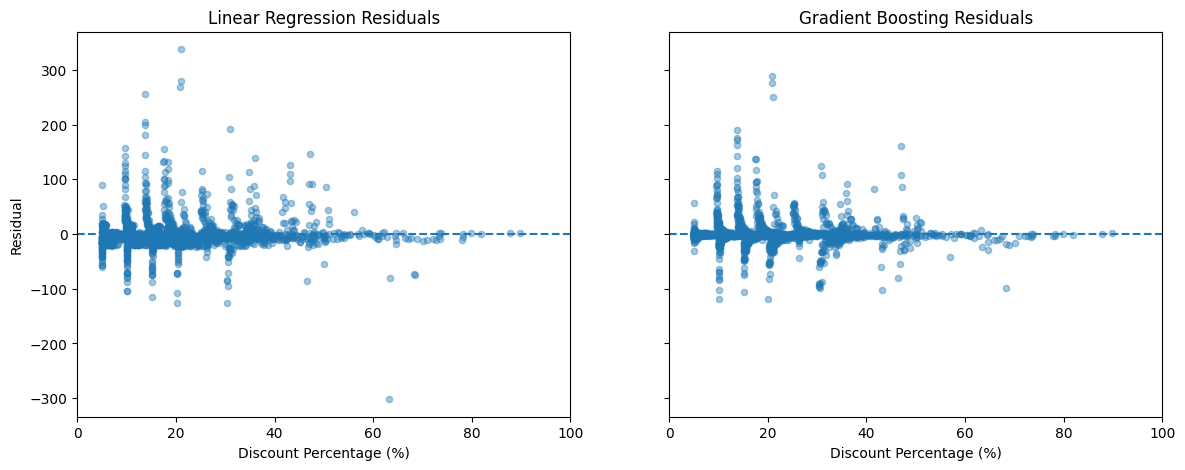

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].scatter(discount_pct_test, residuals_lr, alpha=0.4, s=20)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Linear Regression Residuals")
axes[0].set_xlabel("Discount Percentage (%)")
axes[0].set_ylabel("Residual")
axes[0].set_xlim(0, 100) # Set x-axis limits

axes[1].scatter(discount_pct_test, residuals_gbr, alpha=0.4, s=20)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Gradient Boosting Residuals")
axes[1].set_xlabel("Discount Percentage (%)")
axes[1].set_xlim(0, 100) # Set x-axis limits

plt.show()

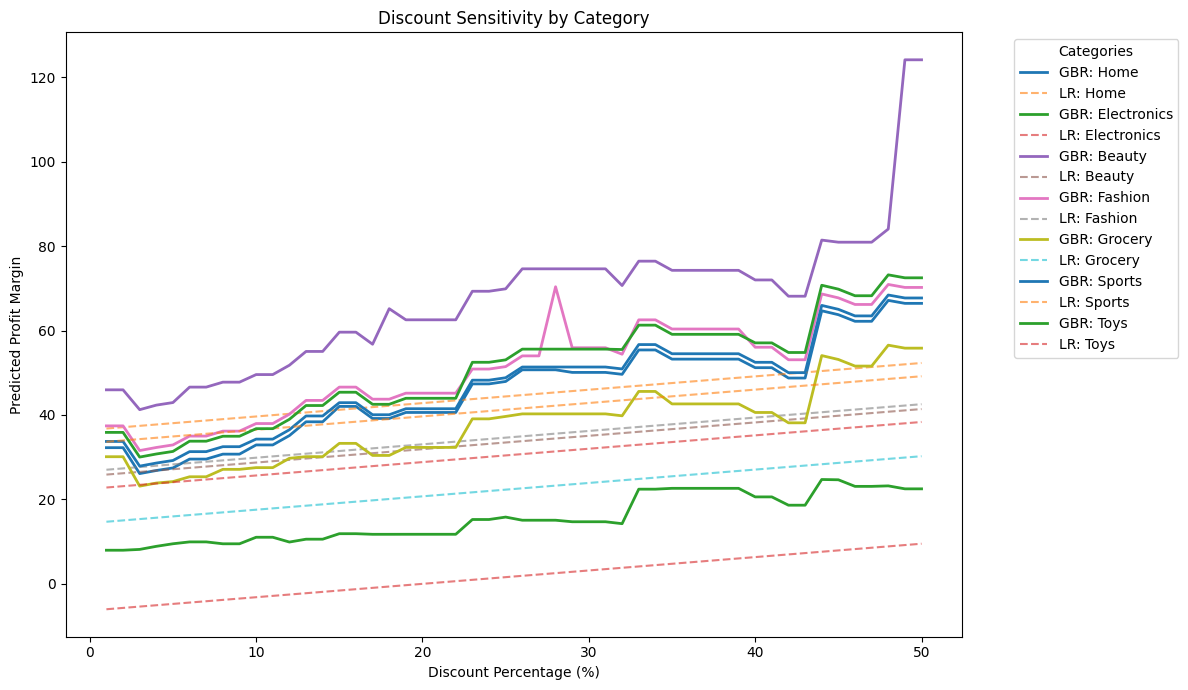

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Identify all unique categories from the original data
all_categories = df_discounted['category'].unique()

# Discount grid: 1% to 50%
discount_grid = np.linspace(0.01, 0.50, 50)
quantity = 1
baseline_unit_revenue = X_train["unit_revenue"].mean()
baseline_discount = X_train["discount_value"].mean() / (
    X_train["unit_revenue"].mean() + X_train["discount_value"].mean()
)
base_price = baseline_unit_revenue / (1 - baseline_discount)

plt.figure(figsize=(12, 7))

# Loop through every category to create lines
for cat in all_categories:
    sim_rows = []
    for d in discount_grid:
        # Price mechanics
        discount_value = base_price * d * quantity
        unit_revenue = base_price * (1 - d)

        # Create row with basic features
        row = {
            "discount_value": discount_value,
            "unit_revenue": unit_revenue,
            "category": cat # Temporary column for alignment
        }
        sim_rows.append(row)

    temp_df = pd.DataFrame(sim_rows)

    # 2. Replicate the exact Pre-processing used in training
    # For LR (drop_first=True logic)
    X_lr = pd.get_dummies(temp_df, columns=['category']).reindex(columns=linear_model_discounted.feature_names_in_, fill_value=0)

    # For GBR (Full encoding logic)
    X_gbr = pd.get_dummies(temp_df, columns=['category']).reindex(columns=gbr_model_discounted.feature_names_in_, fill_value=0)

    # 3. Generate Predictions
    preds_lr = linear_model_discounted.predict(X_lr)
    preds_gbr = gbr_model_discounted.predict(X_gbr)

    # 4. Plotting (Solid for GBR, Dashed for LR to tell them apart)
    plt.plot(discount_grid * 100, preds_gbr, label=f"GBR: {cat}", linewidth=2)
    plt.plot(discount_grid * 100, preds_lr, label=f"LR: {cat}", linestyle='--', alpha=0.6)

plt.xlabel("Discount Percentage (%)")
plt.ylabel("Predicted Profit Margin")
plt.title("Discount Sensitivity by Category")

# --- ADDED CODE TO SHOW LABELS ---
plt.legend(title="Categories", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
# --------------------------------

plt.show()

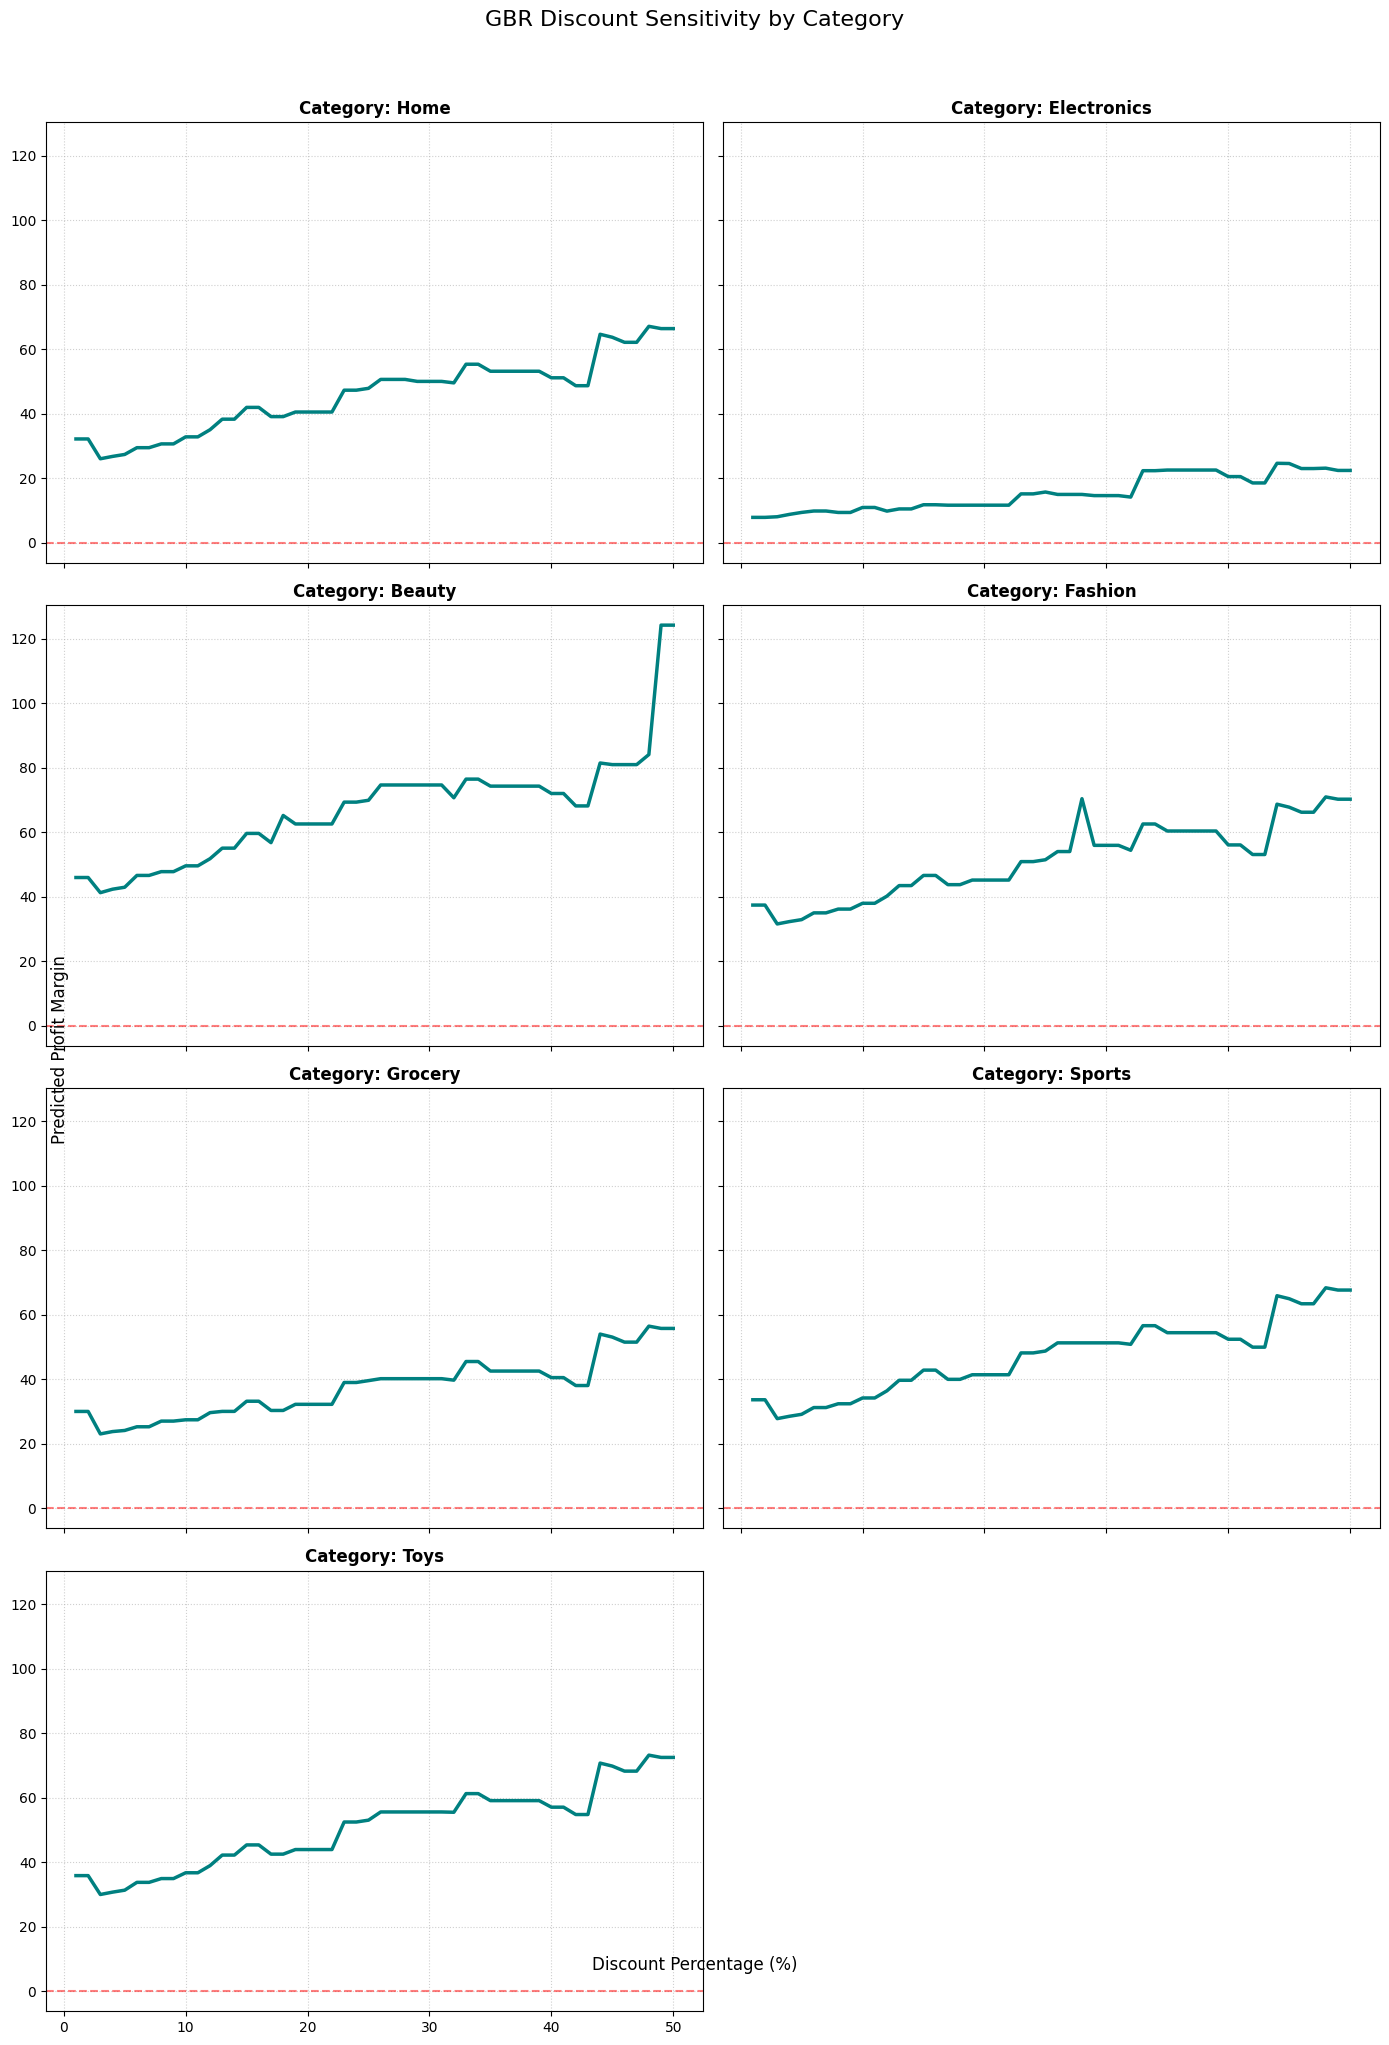

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# 1. Setup Data and Categories
all_categories = df_discounted['category'].unique()
num_cats = len(all_categories)
discount_grid = np.linspace(0.01, 0.50, 50)
quantity = 1

# Calculate grid dimensions (e.g., if 4 categories, 2x2 grid)
cols = 2
rows = math.ceil(num_cats / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 5), sharex=True, sharey=True)
axes = axes.flatten() # Flatten to loop easily

# 2. Reuse your baseline logic
baseline_unit_revenue = X_train["unit_revenue"].mean()
baseline_discount = X_train["discount_value"].mean() / (
    X_train["unit_revenue"].mean() + X_train["discount_value"].mean()
)
base_price = baseline_unit_revenue / (1 - baseline_discount)

# 3. Loop through categories and plot
for i, cat in enumerate(all_categories):
    sim_rows = []
    for d in discount_grid:
        discount_value = base_price * d * quantity
        unit_revenue = base_price * (1 - d)

        row = {
            "discount_value": discount_value,
            "unit_revenue": unit_revenue,
            "category": cat
        }
        sim_rows.append(row)

    temp_df = pd.DataFrame(sim_rows)

    # Align features for GBR (using the full encoding)
    X_gbr = pd.get_dummies(temp_df, columns=['category']).reindex(
        columns=gbr_model_discounted.feature_names_in_, fill_value=0
    )

    # Predict
    preds_gbr = gbr_model_discounted.predict(X_gbr)

    # Plot on the specific subplot axis
    ax = axes[i]
    ax.plot(discount_grid * 100, preds_gbr, color='teal', linewidth=2.5, label='GBR Prediction')
    ax.axhline(0, color='red', linestyle='--', alpha=0.5) # Zero margin baseline
    ax.set_title(f"Category: {cat}", fontsize=12, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6)

# 4. Final Formatting
fig.suptitle("GBR Discount Sensitivity by Category", fontsize=16, y=1.02)
fig.text(0.5, 0.04, 'Discount Percentage (%)', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Predicted Profit Margin', va='center', rotation='vertical', fontsize=12)

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

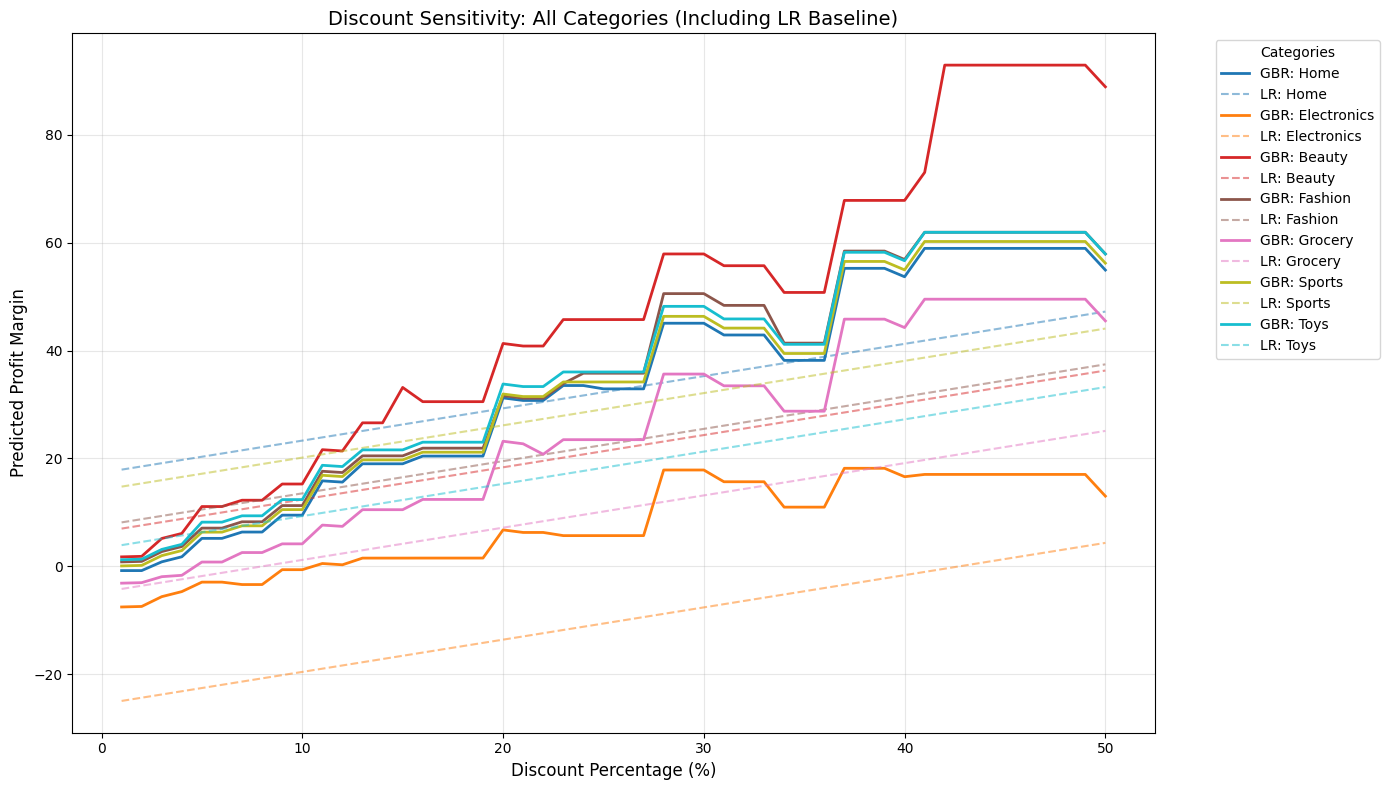

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get ALL categories from the original dataframe
# This ensures even the one "dropped" from the LR columns is included
all_categories = df_discounted['category'].unique()

discount_grid = np.linspace(0.01, 0.50, 50)
quantity = 1
baseline_unit_revenue = df_discounted["price"].mean()
baseline_discount = df_discounted["discount_value"].mean() / (
    df_discounted["unit_revenue"].mean() + df_discounted["discount_value"].mean()
)
base_price = baseline_unit_revenue / (1 - baseline_discount)

plt.figure(figsize=(14, 8))

# Use a colormap to give each category a distinct color
colors = plt.cm.tab10(np.linspace(0, 1, len(all_categories)))

for i, cat in enumerate(all_categories):
    sim_rows = []
    for d in discount_grid:
        discount_value = base_price * d * quantity
        unit_revenue = base_price * (1 - d)
        row = {"discount_value": discount_value, "price": unit_revenue, "category": cat}
        sim_rows.append(row)

    temp_df = pd.DataFrame(sim_rows)

    # LR Processing: reindex handles the "missing" column by filling 0s
    # This triggers the Intercept for the dropped category
    X_lr = pd.get_dummies(temp_df, columns=['category']).reindex(
        columns=linear_model_discounted.feature_names_in_, fill_value=0
    )

    # GBR Processing
    X_gbr = pd.get_dummies(temp_df, columns=['category']).reindex(
        columns=gbr_model_discounted.feature_names_in_, fill_value=0
    )

    # Predictions
    preds_lr = linear_model_discounted.predict(X_lr)
    preds_gbr = gbr_model_discounted.predict(X_gbr)

    # Plotting
    # Note: If this category was the one 'dropped' in LR,
    # the line will still appear correctly based on the model's intercept.
    plt.plot(discount_grid * 100, preds_gbr, label=f"GBR: {cat}", color=colors[i], linewidth=2)
    plt.plot(discount_grid * 100, preds_lr, label=f"LR: {cat}", linestyle='--', color=colors[i], alpha=0.5)

# Create custom legend to explain line styles
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='black', lw=2),
                Line2D([0], [0], color='black', lw=2, linestyle='--')]

plt.xlabel("Discount Percentage (%)", fontsize=12)
plt.ylabel("Predicted Profit Margin", fontsize=12)
plt.title("Discount Sensitivity: All Categories (Including LR Baseline)", fontsize=14)
plt.legend(title="Categories", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipython-input-4220625958.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(all_categories))


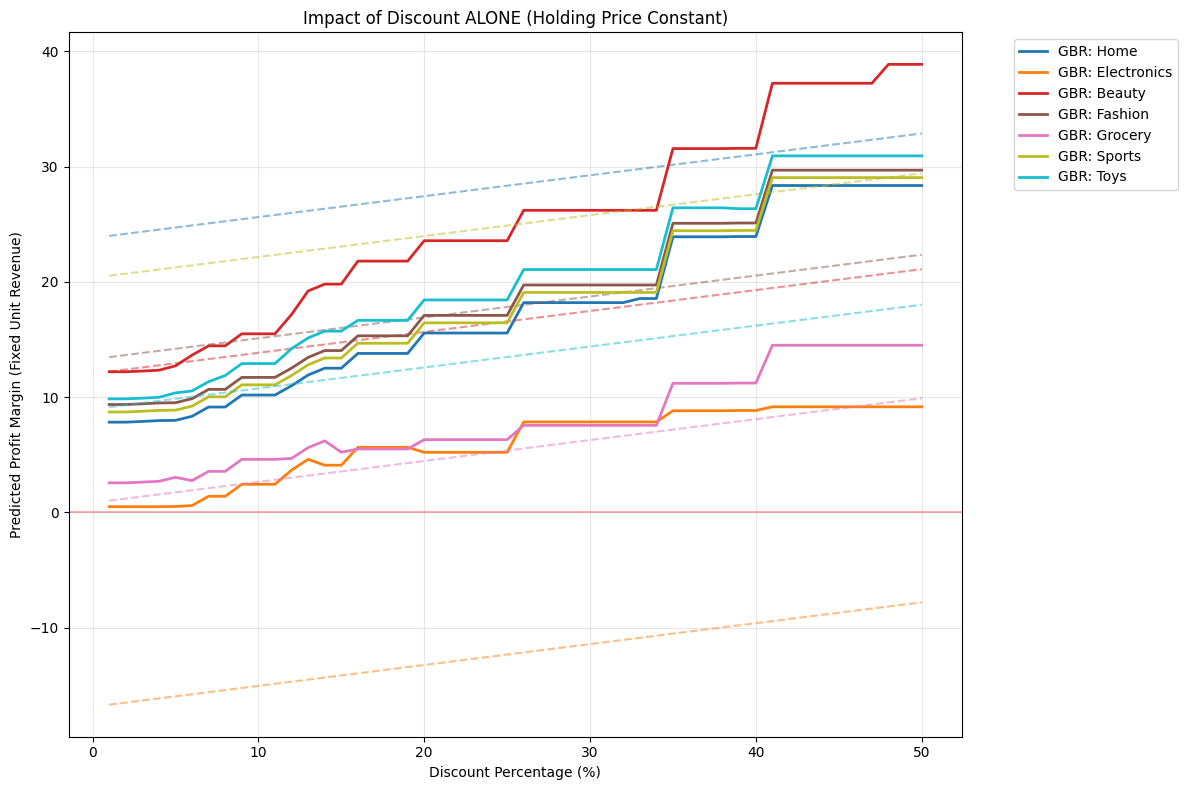

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup constants
discount_grid = np.linspace(0.01, 0.50, 50)
quantity = 1

# Use the MEDIAN unit revenue to avoid being skewed by high-price outliers
fixed_unit_revenue = X_train["price"].median()

# Identify all unique categories
all_categories = df_discounted['category'].unique()

plt.figure(figsize=(12, 8))
colors = plt.cm.get_cmap('tab10', len(all_categories))

for i, cat in enumerate(all_categories):
    sim_rows = []

    for d in discount_grid:
        # THE TEST: We keep unit_revenue FIXED.
        # We only change the discount_value (d * fixed_unit_revenue)
        # This removes the "High Price = High Discount" bias
        discount_impact = fixed_unit_revenue * d

        row = {
            "discount_value": discount_impact,
            "price": fixed_unit_revenue,
            "category": cat
        }
        sim_rows.append(row)

    temp_df = pd.DataFrame(sim_rows)

    # Align features for LR
    X_lr = pd.get_dummies(temp_df, columns=['category']).reindex(
        columns=linear_model_discounted.feature_names_in_, fill_value=0
    )

    # Align features for GBR
    X_gbr = pd.get_dummies(temp_df, columns=['category']).reindex(
        columns=gbr_model_discounted.feature_names_in_, fill_value=0
    )

    # Predictions
    preds_lr = linear_model_discounted.predict(X_lr)
    preds_gbr = gbr_model_discounted.predict(X_gbr)

    # Plotting
    plt.plot(discount_grid * 100, preds_gbr, label=f"GBR: {cat}", color=colors(i), linewidth=2)
    plt.plot(discount_grid * 100, preds_lr, linestyle='--', color=colors(i), alpha=0.5)

plt.axhline(0, color='red', linestyle='-', alpha=0.3) # Zero line for context
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Predicted Profit Margin (Fixed Unit Revenue)")
plt.title("Impact of Discount ALONE (Holding Price Constant)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Check correlations to see why the lines go up
print("--- Correlation Matrix ---")
print(df[['discount', 'price', 'quantity', 'profit_margin', 'total_amount']].corr())

# Check the 'Top 5' rows for discounted products
print("\n--- Sample Data (Discounted Only) ---")
print(df[df['discount'] > 0][['category', 'price', 'discount', 'profit_margin']].head())

# Check the average margin per discount bucket
df['discount_bucket'] = pd.cut(df['discount'], bins=5)
print("\n--- Mean Profit Margin by Discount Bucket ---")
print(df.groupby('discount_bucket')['profit_margin'].mean())

--- Correlation Matrix ---
               discount     price  quantity  profit_margin  total_amount
discount       1.000000  0.008736 -0.008431      -0.047470     -0.031202
price          0.008736  1.000000  0.005324       0.679105      0.801426
quantity      -0.008431  0.005324  1.000000       0.388398      0.304134
profit_margin -0.047470  0.679105  0.388398       1.000000      0.893327
total_amount  -0.031202  0.801426  0.304134       0.893327      1.000000

--- Sample Data (Discounted Only) ---
      category   price  discount  profit_margin
0         Home  164.08      0.15          31.17
2  Electronics  175.58      0.05          13.44
4         Home   16.33      0.15           1.15
5       Beauty   53.91      0.10          37.35
8      Fashion    6.61      0.05          -1.23

--- Mean Profit Margin by Discount Bucket ---
discount_bucket
(-0.0003, 0.06]    29.430355
(0.06, 0.12]       26.041255
(0.12, 0.18]       24.951660
(0.18, 0.24]       22.670585
(0.24, 0.3]        19.429645


/tmp/ipython-input-4063748294.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('discount_bucket')['profit_margin'].mean())
